# Task #8 — EDA: Léxico (baseline) vs. LLM (CopomLens)

**Objetivo:** comparar, lado a lado, o score do **baseline léxico** (task #5) com o score do
**`extract_tone()`** via LLM (task #4) sobre o mesmo conjunto de atas/comunicados.

**Contrato de dados (não mudar sem avisar o time):**

| Arquivo | Produzido por | Chave de join |
|---|---|---|
| `data/processed/copom_dataset.jsonl` | Task #3 (`feat/pit-dataset`) | `numero_reuniao` + `tipo` |
| `data/processed/tone_results.jsonl` | Task #4 (`feat/extract-tone-poc`, `python -m copom.models`) | `numero_reuniao` + `tipo` |

O schema de `tone_results.jsonl` é exatamente o retorno de `extract_tone()`
(`stance`, `stance_delta`, `forward_guidance`, `incerteza`, `conviccao`, `justificativa`,
`stability`, `model_id`, `seed`, `prompt_version`, `numero_reuniao`, `tipo`, `available_time`).
Documentos que falharam na extração aparecem como linha com chave `error` (sem `stance`) —
o notebook filtra essas linhas e reporta quantas foram descartadas.

> Nota: a chave de join é `numero_reuniao` + `tipo` (não `filename`) porque `extract_tone()`
> não devolve o nome do arquivo — só metadados da reunião. Uma mesma reunião pode ter
> `tipo="ata"` e `tipo="comunicado"`, por isso as duas colunas juntas.

> **Enquanto o #4 não tinha saído:** este notebook rodava só com o léxico, e a seção do LLM
> aparecia vazia/avisando. **Agora que o #4 saiu** (`feat/extract-tone-poc`), basta rodar
> `python -m copom.models` pra gerar `tone_results.jsonl` e todas as células abaixo funcionam
> sem alteração.

In [47]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, str(Path.cwd().parent / "src"))

from copom.features.lexico import calcular_lexico

DATA_DIR = Path("../data/processed")
DATASET_PATH = DATA_DIR / "copom_dataset.jsonl"      # saída da task #3
TONE_PATH = DATA_DIR / "tone_results.jsonl"           # saída da task #4 (python -m copom.models)

JOIN_KEYS = ["numero_reuniao", "tipo"]


## 1. Carregar o dataset point-in-time (task #3)

In [48]:
def load_jsonl(path: Path) -> pd.DataFrame:
    """Lê um .jsonl e devolve DataFrame vazio (com aviso) se o arquivo ainda não existir."""
    if not path.exists():
        print(f"[aviso] {path} ainda não existe — pulando por enquanto.")
        return pd.DataFrame()
    rows = [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]
    return pd.DataFrame(rows)


df_docs = load_jsonl(DATASET_PATH)
df_docs


,available_time,tipo,numero_reuniao,data_reuniao,filename,text
0,2026-06-23,ata,279,2026-06-17,ata_279_2026-06-17.txt,A) Atualização da conjuntura econômica e do ce...
1,2026-05-05,ata,278,2026-04-29,ata_278_2026-04-29.txt,A) Atualização da conjuntura econômica e do ce...
2,2026-03-24,ata,277,2026-03-18,ata_277_2026-03-18.txt,A) Atualização da conjuntura econômica e do ce...
3,2026-02-03,ata,276,2026-01-28,ata_276_2026-01-28.txt,A) Atualização da conjuntura econômica e do ce...
4,2025-12-16,ata,275,2025-12-10,ata_275_2025-12-10.txt,A) Atualização da conjuntura econômica e do ce...
5,2026-06-17,comunicado,279,2026-06-17,comunicado_279_2026-06-17.txt,​O ambiente externo permanece incerto em funçã...
6,2026-04-29,comunicado,278,2026-04-29,comunicado_278_2026-04-29.txt,"​O ambiente externo permanece incerto, em funç..."
7,2026-03-18,comunicado,277,2026-03-18,comunicado_277_2026-03-18.txt,"​O ambiente externo tornou-se mais incerto, em..."
8,2026-01-28,comunicado,276,2026-01-28,comunicado_276_2026-01-28.txt,O ambiente externo ainda se mantém incerto em ...
9,2025-12-10,comunicado,275,2025-12-10,comunicado_275_2025-12-10.txt,​O ambiente externo ainda se mantém incerto em...


## 2. Aplicar o baseline léxico (task #5 — já pronto)

In [49]:
def aplicar_lexico(df: pd.DataFrame) -> pd.DataFrame:
    """Roda calcular_lexico() em cada linha e expande o resultado em colunas prefixadas 'lex_'."""
    if df.empty:
        return df
    resultados = df["text"].apply(calcular_lexico).apply(pd.Series).add_prefix("lex_")
    return pd.concat([df, resultados], axis=1)


df_lex = aplicar_lexico(df_docs)
df_lex[["filename", "numero_reuniao", "tipo", "lex_score", "lex_n_hawkish", "lex_n_dovish"]] if not df_lex.empty else df_lex


,filename,numero_reuniao,tipo,lex_score,lex_n_hawkish,lex_n_dovish
0,ata_279_2026-06-17.txt,279,ata,0.1000,11,9
1,ata_278_2026-04-29.txt,278,ata,0.1000,11,9
2,ata_277_2026-03-18.txt,277,ata,0.1000,11,9
3,ata_276_2026-01-28.txt,276,ata,0.0000,11,11
4,ata_275_2025-12-10.txt,275,ata,0.1429,12,9
5,comunicado_279_2026-06-17.txt,279,comunicado,0.4286,10,4
6,comunicado_278_2026-04-29.txt,278,comunicado,0.3333,10,5
7,comunicado_277_2026-03-18.txt,277,comunicado,0.2500,10,6
8,comunicado_276_2026-01-28.txt,276,comunicado,0.0667,8,7
9,comunicado_275_2025-12-10.txt,275,comunicado,0.2000,9,6


## 3. Carregar o output do LLM (task #4 — `extract_tone()`)

Filtra automaticamente linhas de erro (documentos que falharam na extração, sem `stance`)
e reporta quantas foram descartadas.

In [50]:
df_tone_raw = load_jsonl(TONE_PATH)

LLM_PENDENTE = df_tone_raw.empty
if LLM_PENDENTE:
    print("Task #4 ainda não tem output em tone_results.jsonl — seguindo só com o léxico por enquanto.")
    df_llm = pd.DataFrame()
else:
    n_total = len(df_tone_raw)
    df_llm = df_tone_raw[df_tone_raw.get("error").isna()] if "error" in df_tone_raw.columns else df_tone_raw
    n_erro = n_total - len(df_llm)
    if n_erro:
        print(f"[aviso] {n_erro}/{n_total} documentos com erro de extração — descartados desta EDA.")
    df_llm = df_llm.drop(columns=["stability", "error"], errors="ignore").add_prefix("llm_")
    df_llm = df_llm.rename(columns={f"llm_{k}": k for k in JOIN_KEYS})
    print(f"{len(df_llm)} documentos com score do LLM carregados.")


10 documentos com score do LLM carregados.


## 4. Merge léxico + LLM (join por `numero_reuniao, tipo`)

In [51]:
if LLM_PENDENTE:
    df_eda = df_lex.copy()
else:
    df_eda = df_lex.merge(df_llm, on=JOIN_KEYS, how="left")

df_eda


,available_time,tipo,numero_reuniao,data_reuniao,filename,text,lex_score,lex_n_hawkish,lex_n_dovish,lex_palavras_hawkish,...,llm_stance,llm_stance_delta,llm_incerteza,llm_conviccao,llm_forward_guidance,llm_justificativa,llm_model_id,llm_seed,llm_prompt_version,llm_available_time
0,2026-06-23,ata,279,2026-06-17,ata_279_2026-06-17.txt,A) Atualização da conjuntura econômica e do ce...,0.1000,11,9,"[elevação, alta, aceleração, contracionista, r...",...,0.6,-0.1,0.8,0.9,afrouxamento,O Comitê reafirma serenidade e cautela na cond...,meta-llama/llama-3.1-8b-instruct,42,copom_v1,2026-06-23
1,2026-05-05,ata,278,2026-04-29,ata_278_2026-04-29.txt,A) Atualização da conjuntura econômica e do ce...,0.1000,11,9,"[elevação, alta, aceleração, contracionista, r...",...,0.2,-0.1,0.8,0.6,afrouxamento,O Comitê julgou apropriado dar sequência ao ci...,meta-llama/llama-3.1-8b-instruct,42,copom_v1,2026-05-05
2,2026-03-24,ata,277,2026-03-18,ata_277_2026-03-18.txt,A) Atualização da conjuntura econômica e do ce...,0.1000,11,9,"[elevação, alta, aceleração, contracionista, r...",...,0.2,0.1,0.8,0.6,afrouxamento,"O Comitê avalia que perseverança, firmeza e se...",meta-llama/llama-3.1-8b-instruct,42,copom_v1,2026-03-24
3,2026-02-03,ata,276,2026-01-28,ata_276_2026-01-28.txt,A) Atualização da conjuntura econômica e do ce...,0.0000,11,11,"[elevação, alta, deterioração, aceleração, con...",...,0.2,-0.1,0.6,0.8,afrouxamento,O Comitê avalia que a condução cautelosa da po...,meta-llama/llama-3.1-8b-instruct,42,copom_v1,2026-02-03
4,2025-12-16,ata,275,2025-12-10,ata_275_2025-12-10.txt,A) Atualização da conjuntura econômica e do ce...,0.1429,12,9,"[elevação, alta, deterioração, aceleração, con...",...,0.5,0.0,0.8,0.9,manutencao,"O Comitê avalia que a estratégia em curso, de ...",meta-llama/llama-3.1-8b-instruct,42,copom_v1,2025-12-16
5,2026-06-17,comunicado,279,2026-06-17,comunicado_279_2026-06-17.txt,​O ambiente externo permanece incerto em funçã...,0.4286,10,4,"[elevação, alta, pressões, aceleração, contrac...",...,0.2,-0.1,0.8,0.6,afrouxamento,"O Comitê julgou apropriado, nesse momento, dar...",meta-llama/llama-3.1-8b-instruct,42,copom_v1,2026-06-17
6,2026-04-29,comunicado,278,2026-04-29,comunicado_278_2026-04-29.txt,"​O ambiente externo permanece incerto, em funç...",0.3333,10,5,"[elevação, alta, pressões, aceleração, contrac...",...,0.2,-0.1,0.8,0.6,afrouxamento,O Comitê julgou apropriado dar sequência ao ci...,meta-llama/llama-3.1-8b-instruct,42,copom_v1,2026-04-29
7,2026-03-18,comunicado,277,2026-03-18,comunicado_277_2026-03-18.txt,"​O ambiente externo tornou-se mais incerto, em...",0.2500,10,6,"[elevação, alta, pressões, aceleração, contrac...",...,0.2,-0.1,0.8,0.6,afrouxamento,O Comitê julgou apropriado dar início ao ciclo...,meta-llama/llama-3.1-8b-instruct,42,copom_v1,2026-03-18
8,2026-01-28,comunicado,276,2026-01-28,comunicado_276_2026-01-28.txt,O ambiente externo ainda se mantém incerto em ...,0.0667,8,7,"[alta, pressões, aceleração, cautela, incertez...",...,0.2,-0.1,0.8,0.6,afrouxamento,"O Comitê antevê, em se confirmando o cenário e...",meta-llama/llama-3.1-8b-instruct,42,copom_v1,2026-01-28
9,2025-12-10,comunicado,275,2025-12-10,comunicado_275_2025-12-10.txt,​O ambiente externo ainda se mantém incerto em...,0.2000,9,6,"[alta, pressões, aceleração, contracionista, c...",...,0.2,-0.1,0.8,0.6,afrouxamento,O Comitê segue acompanhando os anúncios refere...,meta-llama/llama-3.1-8b-instruct,42,copom_v1,2025-12-10


## 5. EDA — distribuição do score léxico

Roda sempre, independente do #4 já ter saído ou não.

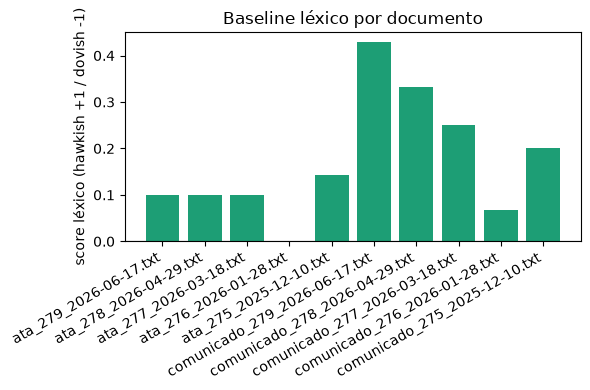

In [52]:
if not df_eda.empty:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(df_eda["filename"], df_eda["lex_score"], color="#1D9E75")
    ax.axhline(0, color="#444441", linewidth=0.8)
    ax.set_ylabel("score léxico (hawkish +1 / dovish -1)")
    ax.set_title("Baseline léxico por documento")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Sem dados ainda — rode a task #3 primeiro.")


## 6. EDA — léxico vs. LLM (a comparação-chave da task #8)

Essa é a célula que gera o resultado-manchete do sprint (§7 do `Realinhamento_Equipe.md`):
o LLM concorda com o léxico? Onde diverge? **Só produz gráfico quando houver linhas do #4 com
sucesso**; até lá (ou se tudo deu erro), mostra um aviso e segue sem quebrar o notebook.

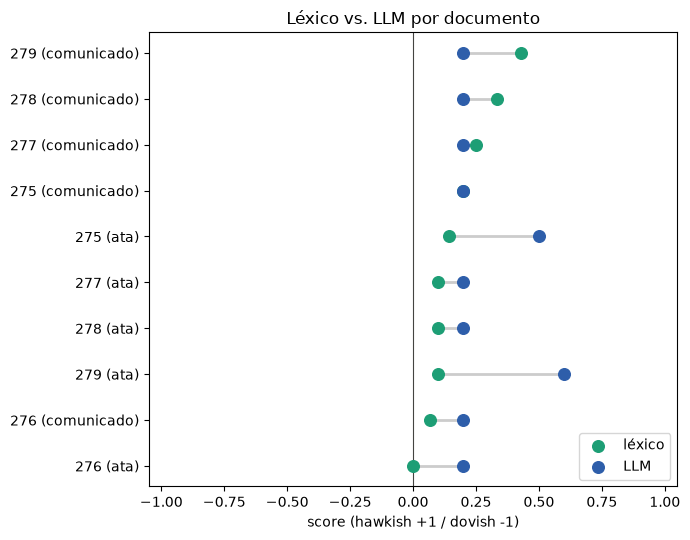

Correlação léxico x LLM (n=10): -0.213
Correlação léxico x LLM (n=10): -0.213
[aviso] llm_stance = 0.2 se repete em 8/10 documentos — correlação pode não ser confiável (LLM pode estar travando na saída).


In [ ]:
tem_llm_valido = (not LLM_PENDENTE) and ("llm_stance" in df_eda.columns) and df_eda["llm_stance"].notna().any()

if not tem_llm_valido:
    print("Aguardando task #4 (extract_tone) com pelo menos um resultado válido para comparar com o léxico.")
else:
    df_plot = df_eda.dropna(subset=["llm_stance"]).copy()

    # Rótulo por documento (número + tipo, pra diferenciar ata de comunicado
    # da mesma reunião) e ordenação por score léxico — cada documento vira
    # uma linha própria no eixo Y, então não tem como dois rótulos colidirem.
    df_plot["rotulo"] = df_plot["numero_reuniao"].astype(str) + " (" + df_plot["tipo"] + ")"
    df_plot = df_plot.sort_values("lex_score").reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(7, 0.4 * len(df_plot) + 1.5))
    y = range(len(df_plot))

    ax.hlines(y, df_plot["lex_score"], df_plot["llm_stance"], color="#CCCCCC", linewidth=2, zorder=1)
    ax.scatter(df_plot["lex_score"], y, color="#1D9E75", s=70, zorder=3, label="léxico")
    ax.scatter(df_plot["llm_stance"], y, color="#2E5EAA", s=70, zorder=3, label="LLM")

    ax.axvline(0, color="#444441", linewidth=0.8, zorder=0)
    ax.set_yticks(list(y))
    ax.set_yticklabels(df_plot["rotulo"])
    ax.set_xlim(-1.05, 1.05)
    ax.set_xlabel("score (hawkish +1 / dovish -1)")
    ax.set_title("Léxico vs. LLM por documento")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    correlacao = df_plot[["lex_score", "llm_stance"]].corr().iloc[0, 1]
    print(f"Correlação léxico x LLM (n={len(df_plot)}): {correlacao:.3f}")

    correlacao = df_plot[["lex_score", "llm_stance"]].corr().iloc[0, 1]
    print(f"Correlação léxico x LLM (n={len(df_plot)}): {correlacao:.3f}")

    # Aviso: se o LLM devolveu o mesmo stance pra vários documentos diferentes,
    # a correlação fica pouco confiável (ela passa a ser puxada só pelos poucos
    # pontos que variam, não pelo conjunto todo) — provável sinal de bug no
    # extract_tone() travando a saída num valor fixo.
    valores_repetidos = contagem_valores[contagem_valores > 1]
    if not valores_repetidos.empty:
        for valor, n in valores_repetidos.items():
            print(f"[aviso] llm_stance = {valor} se repete em {n}/{len(df_plot)} documentos "
                  f"— correlação pode não ser confiável (LLM pode estar travando na saída).")


## 7. Salvar o dataset combinado

Sempre salva o que tiver disponível — léxico sozinho enquanto o #4 não sai (ou não tem
resultado válido), léxico+LLM depois.

In [54]:
OUT_PATH = DATA_DIR / "eda_lexico_vs_llm.csv"
df_eda.to_csv(OUT_PATH, index=False)
status = "incluído" if tem_llm_valido else "pendente/sem resultado válido"
print(f"Salvo em {OUT_PATH} ({len(df_eda)} linhas, LLM {status})")


Salvo em ../data/processed/eda_lexico_vs_llm.csv (10 linhas, LLM incluído)
